## 1. Example sử dụng LangGraph với ChatGroq Llama 3


In [ ]:
import os
from typing import Annotated, TypedDict, Literal
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage
from dotenv import load_dotenv
# Thiết lập API Key (Bạn lấy key miễn phí tại console.groq.com)
load_dotenv("../.env")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# 1. Định nghĩa cấu trúc State
class State(TypedDict):
    # add_messages cực kỳ quan trọng ở đây để giữ lịch sử khi vòng lặp xảy ra
    messages: Annotated[list, add_messages]

# Khởi tạo Model (Dùng Llama 3 cho nhanh và thông minh)
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

# 2. Định nghĩa các Node
def writer_node(state: State):
    print("\n--- 📝 WRITER ĐANG VIẾT... ---")
    # Writer sẽ nhìn vào toàn bộ lịch sử (bao gồm cả lời phê bình của Critic)
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

def critic_node(state: State):
    print("--- 🧐 CRITIC ĐANG KIỂM TRA... ---")
    last_message = state["messages"][-1].content
    
    # Giả sử yêu cầu bài viết phải có từ khóa "AI MLOps"
    if "AI MLOps" not in last_message:
        feedback = SystemMessage(content="Bài viết của bạn chưa có từ khóa 'AI MLOps'. Hãy viết lại và lồng ghép từ khóa này vào một cách tự nhiên.")
        return {"messages": [feedback]}
    
    return state

# 3. Logic điều hướng (Conditional Edge)
def judge_logic(state: State) -> Literal["continue", "end"]:
    # Nếu tin nhắn cuối cùng là từ Critic (SystemMessage), bắt quay lại Writer
    if isinstance(state["messages"][-1], SystemMessage):
        print("--- ❌ CHƯA ĐẠT: Quay lại Writer để sửa... ---")
        return "continue"
    
    print("--- ✅ ĐẠT YÊU CẦU: Kết thúc quy trình. ---")
    return "end"

# 4. Xây dựng đồ thị
workflow = StateGraph(State)

workflow.add_node("writer", writer_node)
workflow.add_node("critic", critic_node)

workflow.add_edge(START, "writer")
workflow.add_edge("writer", "critic")

workflow.add_conditional_edges(
    "critic",
    judge_logic,
    {
        "continue": "writer",
        "end": END
    }
)

# 5. Compile
app = workflow.compile()

# Chạy thử nghiệm
if __name__ == "__main__":
    initial_input = {"messages": [HumanMessage(content="Hãy viết 1 câu giới thiệu ngắn về bản thân bạn.")]}
    
    for event in app.stream(initial_input):
        for value in event.values():
            if "messages" in value:
                print(value["messages"][-1].content)


--- 📝 WRITER ĐANG VIẾT... ---
Xin chào, tôi là trợ lý ảo, luôn sẵn lòng hỗ trợ và cung cấp thông tin hữu ích cho bạn.
--- 🧐 CRITIC ĐANG KIỂM TRA... ---
--- ❌ CHƯA ĐẠT: Quay lại Writer để sửa... ---
Bài viết của bạn chưa có từ khóa 'AI MLOps'. Hãy viết lại và lồng ghép từ khóa này vào một cách tự nhiên.

--- 📝 WRITER ĐANG VIẾT... ---
Tôi cũng rất quan tâm đến lĩnh vực công nghệ, đặc biệt là AI MLOps, và luôn cập nhật kiến thức để mang lại thông tin chính xác và hữu ích cho người dùng.
--- 🧐 CRITIC ĐANG KIỂM TRA... ---
--- ✅ ĐẠT YÊU CẦU: Kết thúc quy trình. ---
Tôi cũng rất quan tâm đến lĩnh vực công nghệ, đặc biệt là AI MLOps, và luôn cập nhật kiến thức để mang lại thông tin chính xác và hữu ích cho người dùng.


## 2. Build Application Hợp đồng Bất động sản với LangGraph

In [ ]:
import os
from typing import Annotated, TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver

# Thiết lập API Key (Bạn lấy key miễn phí tại console.groq.com)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# 1. Định nghĩa cấu trúc State
class State(TypedDict):
    messages: Annotated[list, add_messages]
    is_review_ok: bool  # Thêm dòng này
    is_security_ok: bool  # Thêm dòng này

# Khởi tạo Model (Dùng Llama 3 cho nhanh và thông minh)
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

def drafter(state: State): 
  print("========= Đang soạn bản thảo cho hợp đồng")
  messages = llm.invoke(input=[{"role": "system", "content": "Bạn là 1 nhà soạn thảo hợp đồng dựa vào yêu cầu của user"}, 
                               *state['messages']])
  return {"messages": messages}


class ReviewResult(BaseModel):
    is_ok: bool = Field(description="True nếu hợp đồng đầy đủ điều khoản, False nếu thiếu")
    feedback: str = Field(description="Lời phê bình hoặc yêu cầu sửa đổi")
    
def legal_reviewer(state: State): 
  print("XXXXXXXXXX Đang đánh giá hợp đồng")
  llm_with_structed = llm.with_structured_output(ReviewResult)
  messages = llm_with_structed.invoke(input=[{"role": "system", "content": "Bạn là 1 người đánh giá chất lượng cho bản hợp đồng khắt khe. Hãy đánh giá bản hợp đồng do AI tạo ra, hãy kiểm tra xem hợp đồng đã đủ các điều khoản bảo mật chưa"}, 
                         {"role": "user", "content": state['messages'][-1].content}])
  return {"is_review_ok": messages.is_ok, "messages": [messages.feedback]}


class SecurityResult(BaseModel): 
   is_ok: bool = Field(description="True nếu hợp đồng không lộ thông tin bảo mật, False nếu để lộ")
   feedback: str = Field(description="Lời phê bình hoặc yêu cầu sửa đổi")
   
def security_checker(state: State): 
  print("------------ Đang kiểm tra thông tin hợp đồng")
  llm_with_structed = llm.with_structured_output(SecurityResult)
  messages = llm_with_structed.invoke(input=[{"role": "system", "content": "Bạn là 1 người bảo vệ hợp đồng, nhiệm vụ là check xem hợp đồng có lộ thông tin bảo mật không"}, 
                               {"role": "user", "content": state['messages'][-1].content}])
  
  return {"is_security_ok": messages.is_ok, "messages": [messages.feedback]}


def condition_review(state: State): 
  if state['is_review_ok']: 
    print("Hợp đồng đánh giá chưa đủ diều kiện")
    return "pass"
  return "failed"

def condition_security(state: State): 
  if state['is_security_ok']: 
    print("Hợp đồng đánh giá chưa đủ độ bảo mật")
    return "pass"
  return "failed"

workflow = StateGraph(state_schema=State)

workflow.add_node("drafter", drafter)
workflow.add_node("legal_reviewer", legal_reviewer)
workflow.add_node("security_checker", security_checker)

workflow.add_edge(start_key=START, end_key="drafter")
workflow.add_edge(start_key="drafter", end_key="legal_reviewer")


workflow.add_conditional_edges(
  "legal_reviewer", 
  condition_review,
  {
     "pass": "security_checker",
     "failed": "drafter"
	}
)
     
workflow.add_conditional_edges(
   "security_checker", 
   condition_security, 
   {
      "pass": END, 
      "failed": "drafter"
	 }
)

app = workflow.compile()

# Chạy thử nghiệm
if __name__ == "__main__":
	initial_input = {"messages": [HumanMessage(content="Hãy viết 1 hợp đồng bán chung cư có giá 1 tỷ")]}
	
	for event in app.stream(initial_input, config={"recursion_limit": 10}):
			for value in event.values():
					if "messages" in value:
							print(value["messages"])

--- AGENT BẮT ĐẦU LÀM VIỆC ---
========= Đang soạn bản thảo cho hợp đồng
XXXXXXXXXX Đang đánh giá hợp đồng

[HỆ THỐNG]: Đang dừng sau Node: False
--- Đợi con người kiểm tra thread hop_dong_001 ---
--- CON NGƯỜI ĐÃ DUYỆT. ĐANG CHẠY TIẾP... ---
========= Đang soạn bản thảo cho hợp đồng
{'messages': AIMessage(content='Tôi hoàn toàn đồng ý với bạn. Dưới đây là một bản hợp đồng thuê nhà được chỉnh sửa và bổ sung để bao gồm các điều khoản bảo mật cần thiết:\n\n**HỢP ĐỒNG THUÊ NHÀ**\n\nSố hợp đồng: [Số hợp đồng]\n\nNgày ký kết: [Ngày ký kết]\n\n**BÊN CHO THUÊ**\n\n* Tên: [Tên bên cho thuê]\n* Địa chỉ: [Địa chỉ bên cho thuê]\n* Số điện thoại: [Số điện thoại bên cho thuê]\n* Số CMND/CCCD: [Số CMND/CCCD bên cho thuê]\n\n**BÊN THUÊ**\n\n* Tên: [Tên bên thuê]\n* Địa chỉ: [Địa chỉ bên thuê]\n* Số điện thoại: [Số điện thoại bên thuê]\n* Số CMND/CCCD: [Số CMND/CCCD bên thuê]\n\n**ĐIỀU 1: ĐỐI TƯỢNG THUÊ**\n\nBên cho thuê đồng ý cho bên thuê thuê nhà tại địa chỉ [Địa chỉ nhà thuê] với diện tích [Diện t

### 2.1 Thêm Human-in-the-Loop vào Graph

In [ ]:
memory = MemorySaver()
app = workflow.compile(interrupt_after=["legal_reviewer"], checkpointer=memory)


config = {"configurable": {"thread_id": "hop_dong_001"}}

if __name__ == "__main__":
    # CHẠY LẦN 1: Agent soạn và Review, sau đó DỪNG
    initial_input = {"messages": [HumanMessage(content="Hợp đồng thuê nhà 10 triệu/tháng")]}
    print("--- AGENT BẮT ĐẦU LÀM VIỆC ---")
    app.invoke(initial_input, config=config)
    
    # Kiểm tra trạng thái
    snapshot = app.get_state(config)
    print(f"\n[HỆ THỐNG]: Đang dừng sau Node: {snapshot.values.get('is_review_ok')}")
    print(f"--- Đợi con người kiểm tra thread {config['configurable']['thread_id']} ---")
    
    # MÔ PHỎNG CON NGƯỜI CAN THIỆP
    user_approval = input("Bạn có đồng ý cho chạy tiếp sang Security Check không? (y/n): ")
    
    if user_approval.lower() == 'y':
        print("--- CON NGƯỜI ĐÃ DUYỆT. ĐANG CHẠY TIẾP... ---")
        # CHẠY TIẾP LẦN 2: Truyền None để chạy từ điểm dừng
        for event in app.stream(None, config=config):
            for value in event.values():
                print(value)
    else:
        print("--- HÀNH ĐỘNG BỊ HỦY BỎ BỞI CON NGƯỜI ---")

## 3. SubGraph trong Langgraph

In [ ]:
import os
from typing import Annotated, TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv

load_dotenv("../.env")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Sử dụng absolute path
persistent_dir = "/home/ducpham/workspace/Multi-Agent-for-Multimodal-Documents/notebooks/chromadb"

# Tạo directory nếu chưa tồn tại
os.makedirs(persistent_dir, exist_ok=True)

loader = PyMuPDFLoader(file_path="/home/ducpham/workspace/Multi-Agent-for-Multimodal-Documents/[Description]_Project_Emoji_Image_Generation.pdf")
splitter = RecursiveCharacterTextSplitter(
	chunk_size=1024,
	chunk_overlap=50,
	length_function=len,
)
documents = loader.load_and_split(text_splitter=splitter)

# Kiểm tra xem collection đã tồn tại chưa
try:
	vector_store = Chroma(collection_name="multi-agent", 
	                      embedding_function=OpenAIEmbeddings(model="text-embedding-3-small", dimensions=768),
	                      persist_directory=persistent_dir)
	# Nếu collection trống, thêm documents
	if len(vector_store.get()['ids']) == 0:
		vector_store.add_documents(documents=documents)
except:
	# Nếu collection chưa tồn tại, tạo mới
	vector_store = Chroma.from_documents(documents=documents,
	                                      collection_name="multi-agent",
	                                      embedding=OpenAIEmbeddings(model="text-embedding-3-small", dimensions=768),
	                                      persist_directory=persistent_dir)

print(f"✅ Vector store đã được tải từ: {persistent_dir}")

✅ Vector store đã được tải từ: /home/ducpham/workspace/Multi-Agent-for-Multimodal-Documents/notebooks/chromadb


In [ ]:
# results = vector_store.similarity_search(query="Mô tả bài toán")
# for doc in results: 
#   print(doc)
#   break

In [63]:
load_dotenv("../.env")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

from langchain_tavily import TavilySearch
from pydantic import BaseModel

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
seacher = TavilySearch(max_results=5)


class State(TypedDict): 
  question: str
  context: list[dict]
  is_retriever_ok: bool
  response: str
  
class RetrieverResult(BaseModel): 
  is_ok: bool = Field(description="True nếu content liên quan tới câu hỏi, False nếu không liên quan")


def pdf_seacher(state: State): 
  print("======= Đang tìm kiếm tài liệu PDF")
  documents = vector_store.similarity_search(query=state['question'].content, k=3)
  return {"context": [{"content": result.page_content} for result in documents]}


def news_seacher(state: State): 
  print("======== Đang tìm kiếm thông tin trên mạng")
  documents = seacher.invoke(input=state['question'].content)
  return {"context": [{"content": f"{result['title']}\n{result['content']}"} for result in documents['results']]}
  

def document_checker(state: State): 
  print("======== Đang kiểm tra tài liệu")
  if not state['context']:
    return {"is_retriever_ok": False}
    
  context_text = "\n---\n".join([c['content'] for c in state['context']])
  messages = [{"role": "system", "content": "Bạn là trợ lý kiểm tra xem thông tin ngữ cảnh có phù hợp để sử dụng cho việc trả lời câu hỏi của user không?"}, 
              {"role": "user", "content": f"Question: {state['question'].content}\n\nContext:\n{context_text}"}]
  
  llm_with_structed = llm.with_structured_output(RetrieverResult)
  response = llm_with_structed.invoke(input=messages)
  return {"is_retriever_ok": response.is_ok}


def condition_retriever(state: State): 
  if state['is_retriever_ok']: 
    print("✅ Có đủ context - END subgraph")
    return "pass"
  print("❌ Context chưa tốt - tìm news")
  return "failed"


workflow = StateGraph(state_schema=State)

workflow.add_node("pdf_seacher", pdf_seacher)
workflow.add_node("document_checker", document_checker)
workflow.add_node("news_seacher", news_seacher)

workflow.add_edge(start_key=START, end_key="pdf_seacher")
workflow.add_edge(start_key='pdf_seacher', end_key='document_checker')
workflow.add_edge(start_key='news_seacher', end_key='document_checker')

workflow.add_conditional_edges(
  "document_checker", 
  condition_retriever, 
  {
    "pass": END,  # 🔑 END với context để gửi cho writer
    "failed": "news_seacher",
	}
)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

# Test subgraph
initial_input = {"question": HumanMessage(content="Bóng đá Việt Nam hôm nay có gì mới"), "context": [], "is_retriever_ok": False, "response": ""}
config = {"configurable": {"thread_id": "subgraph_001"}}
app.invoke(initial_input, config=config)

======= Đang tìm kiếm tài liệu PDF
======== Đang kiểm tra tài liệu
❌ Context chưa tốt - tìm news
======== Đang tìm kiếm thông tin trên mạng
======== Đang kiểm tra tài liệu
✅ Có đủ context - END subgraph


{'question': HumanMessage(content='Bóng đá Việt Nam hôm nay có gì mới', additional_kwargs={}, response_metadata={}),
 'context': [{'content': 'Bóng đá Việt Nam hôm nay tin tức bong da Viet Nam mới nhất\nTiền đạo Nguyễn Đình Bắc không giấu được niềm hạnh phúc sau khi cùng U23 Việt Nam đánh bại U23 UAE tại tứ kết VCK U23 châu Á 2026.'},
  {'content': 'Tin tức Bóng đá Việt Nam hôm nay mới nhất - 24H\n### Video bóng đá HAGL - Công an Hà Nội: Ngoại binh rực sáng, bám đuổi ngôi đầu (V-League). ### Video bóng đá Nam Định - Hà Nội: 2 tuyệt phẩm mãn nhãn (V-League). ### Video bóng đá Hà Nội - PVF-CAND: Đại thắng "4 sao" đầu tiên của mùa giải (V-League). ### Video bóng đá Công an Hà Nội - Công an TP HCM: Thẻ đỏ & bàn thắng bất ngờ (V-League). ### Video bóng đá Becamex TP HCM - Hà Nội: Ngược dòng cảm xúc, Hoàng Hên lập công (V-League). ### Video bóng đá Nam Định - Công an Hà Nội: Dấu ấn Quang Hải, bám sát ngôi đầu (V-League). ### Video bóng đá Công an TP HCM - Nam Định: Dấu ấn Tiến Linh, bỏ lỡ ng

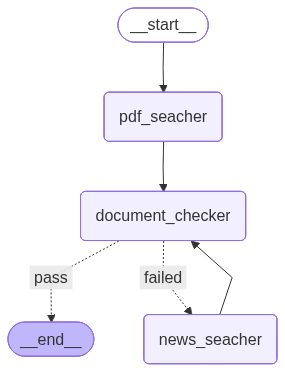

In [60]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [68]:
def writer(state: State): 
  print("\n📝 WRITER ĐANG VIẾT RESPONSE")
  context_text = "\n---\n".join([c['content'] for c in state['context']])
  
  messages = [
    {"role": "system", "content": "Bạn là trợ lý thông minh. Hãy trả lời câu hỏi của user dựa vào ngữ cảnh được cung cấp."},
    {"role": "user", "content": f"Câu hỏi: {state['question'].content}\n\nNgữ cảnh:\n{context_text}"}
  ]
  response = llm.invoke(input=messages)
  return {"response": response.content}


# 🔑 Main Graph gọi subgraph rồi writer
class MainState(TypedDict):
  question: str
  context: list[dict]
  response: str

workflow_main = StateGraph(state_schema=MainState)

# Thêm subgraph như một node
workflow_main.add_node("retriever_subgraph", app)
workflow_main.add_node("writer", writer)

workflow_main.add_edge(START, "retriever_subgraph")
workflow_main.add_edge("retriever_subgraph", "writer")  # 🔑 Context từ subgraph sang writer
workflow_main.add_edge("writer", END)

memory = MemorySaver()
app_main = workflow_main.compile(checkpointer=memory)

# Test main graph
initial_input = {"question": HumanMessage(content="Bóng đá Việt Nam hôm nay có gì mới"), "context": [], "response": ""}
config = {"configurable": {"thread_id": "main_001"}}
result = app_main.invoke(initial_input, config=config)
print(result['response'])

======= Đang tìm kiếm tài liệu PDF
======== Đang kiểm tra tài liệu
❌ Context chưa tốt - tìm news
======== Đang tìm kiếm thông tin trên mạng
======== Đang kiểm tra tài liệu
✅ Có đủ context - END subgraph

📝 WRITER ĐANG VIẾT RESPONSE
Bóng đá Việt Nam hôm nay có nhiều tin tức mới và thú vị. U23 Việt Nam đã đánh bại U23 UAE tại tứ kết VCK U23 châu Á 2026 với tỷ số 3-2, tái hiện tinh thần Thường Châu. Đội trưởng U23 Việt Nam cũng đã phá dớp ở U23 châu Á. Ngoài ra, có nhiều trận đấu hấp dẫn trong V-League, như HAGL - Công an Hà Nội, Nam Định - Hà Nội, Hà Nội - PVF-CAND, Công an Hà Nội - Công an TP HCM, Becamex TP HCM - Hà Nội, Nam Định - Công an Hà Nội, Công an TP HCM - Nam Định. Các trận đấu này đã mang lại nhiều bàn thắng và tình huống thú vị.


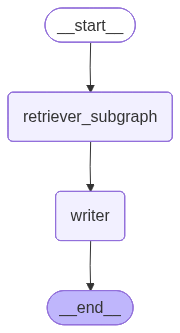

In [69]:
from IPython.display import Image
Image(app_main.get_graph().draw_mermaid_png())

## 4. Router and Parallel

In [70]:
import os
from typing import Annotated, TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv

load_dotenv("../.env")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Sử dụng absolute path
persistent_dir = "/home/ducpham/workspace/Multi-Agent-for-Multimodal-Documents/notebooks/chromadb"

# Tạo directory nếu chưa tồn tại
os.makedirs(persistent_dir, exist_ok=True)

loader = PyMuPDFLoader(file_path="/home/ducpham/workspace/Multi-Agent-for-Multimodal-Documents/[Description]_Project_Emoji_Image_Generation.pdf")
splitter = RecursiveCharacterTextSplitter(
	chunk_size=1024,
	chunk_overlap=50,
	length_function=len,
)
documents = loader.load_and_split(text_splitter=splitter)

# Kiểm tra xem collection đã tồn tại chưa
try:
	vector_store = Chroma(collection_name="multi-agent", 
	                      embedding_function=OpenAIEmbeddings(model="text-embedding-3-small", dimensions=768),
	                      persist_directory=persistent_dir)
	# Nếu collection trống, thêm documents
	if len(vector_store.get()['ids']) == 0:
		vector_store.add_documents(documents=documents)
except:
	# Nếu collection chưa tồn tại, tạo mới
	vector_store = Chroma.from_documents(documents=documents,
	                                      collection_name="multi-agent",
	                                      embedding=OpenAIEmbeddings(model="text-embedding-3-small", dimensions=768),
	                                      persist_directory=persistent_dir)

print(f"✅ Vector store đã được tải từ: {persistent_dir}")

✅ Vector store đã được tải từ: /home/ducpham/workspace/Multi-Agent-for-Multimodal-Documents/notebooks/chromadb


In [84]:
load_dotenv("../.env")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

from langchain_tavily import TavilySearch
from pydantic import BaseModel

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
seacher = TavilySearch(max_results=5)


class RetrieverState(TypedDict): 
  question: str
  context: list[dict]
  is_retriever_ok: bool
  response: str
  
class RetrieverResult(BaseModel): 
  is_ok: bool = Field(description="True nếu content liên quan tới câu hỏi, False nếu không liên quan")


def pdf_seacher(state: RetrieverState): 
  print("======= Đang tìm kiếm tài liệu PDF")
  documents = vector_store.similarity_search(query=state['question'].content, k=3)
  return {"context": [{"content": result.page_content} for result in documents]}


def news_seacher(state: RetrieverState): 
  print("======== Đang tìm kiếm thông tin trên mạng")
  documents = seacher.invoke(input=state['question'].content)
  return {"context": [{"content": f"{result['title']}\n{result['content']}"} for result in documents['results']]}
  

def document_checker(state: RetrieverState): 
  print("======== Đang kiểm tra tài liệu")
  if not state['context']:
    return {"is_retriever_ok": False}
    
  context_text = "\n---\n".join([c['content'] for c in state['context']])
  messages = [{"role": "system", "content": "Bạn là trợ lý kiểm tra xem thông tin ngữ cảnh có phù hợp để sử dụng cho việc trả lời câu hỏi của user không?"}, 
              {"role": "user", "content": f"Question: {state['question'].content}\n\nContext:\n{context_text}"}]
  
  llm_with_structed = llm.with_structured_output(RetrieverResult)
  response = llm_with_structed.invoke(input=messages)
  return {"is_retriever_ok": response.is_ok}


def condition_retriever(state: RetrieverState): 
  if state['is_retriever_ok']: 
    print("✅ Có đủ context - END subgraph")
    return "pass"
  print("❌ Context chưa tốt - tìm news")
  return "failed"


workflow = StateGraph(state_schema=RetrieverState)

workflow.add_node("pdf_seacher", pdf_seacher)
workflow.add_node("document_checker", document_checker)
workflow.add_node("news_seacher", news_seacher)

workflow.add_edge(start_key=START, end_key="pdf_seacher")
workflow.add_edge(start_key='pdf_seacher', end_key='document_checker')
workflow.add_edge(start_key='news_seacher', end_key='document_checker')

workflow.add_conditional_edges(
  "document_checker", 
  condition_retriever, 
  {
    "pass": END,  # 🔑 END với context để gửi cho writer
    "failed": "news_seacher",
	}
)

app = workflow.compile()

# Test subgraph
# initial_input = {"question": HumanMessage(content="Bóng đá Việt Nam hôm nay có gì mới"), "context": [], "is_retriever_ok": False, "response": ""}
# config = {"configurable": {"thread_id": "subgraph_001"}}
# app.invoke(initial_input, config=config)

In [ ]:
class MainState(TypedDict):
  question: str
  context: list[dict]
  next_action: str
  response: str
  
class RouterDecision(BaseModel): 
  next_action: Literal["writer", "seacher"] = \
    Field(description="Chọn seacher nếu câu hỏi cần tìm thêm thông tin, chọn writer nếu câu hỏi có thể trả lời ngay mà không cần thông tin")
  reason: str = Field(description="Lí do chọn bước tiếp theo")

def writer(state: MainState): 
  print("\n📝 WRITER ĐANG VIẾT RESPONSE")
  context_text = "\n---\n".join([c['content'] for c in state['context']]) if state.get('context', None) else None
  
  messages = [
    {"role": "system", "content": "Bạn là trợ lý thông minh. Hãy trả lời câu hỏi của user dựa vào ngữ cảnh nếu được cung cấp."},
    {"role": "user", "content": f"Câu hỏi: {state['question'].content}\n\nNgữ cảnh:\n{context_text}"}
  ]
  response = llm.invoke(input=messages)
  return {"response": response.content}


def router(state: MainState): 
  messages = [
    {"role": "system", "content": "Bạn là chuyên gia phân loại câu hỏi."},
    {"role": "user", "content": state['question'].content}
  ]
  llm_with_structured = llm.with_structured_output(RouterDecision)
  response = llm_with_structured.invoke(input=messages)
  action = response.next_action
  print(f"CHỌN BƯỚC: {action}. Lí do: {response.reason}")
  return {'next_action': action}
  
def router_condition(state: MainState): 
  if state['next_action'] == "writer": 
    return "writer"
  return "seacher"

workflow_main = StateGraph(state_schema=MainState)

workflow_main.add_node("router", router)
workflow_main.add_node("retriever_subgraph", app)
workflow_main.add_node("writer", writer)

workflow_main.add_edge(START, "router")
workflow_main.add_edge("retriever_subgraph", "writer")  # 🔑 Context từ subgraph sang writer
workflow_main.add_edge("writer", END)


workflow_main.add_conditional_edges(
  "router", 
  router_condition, 
  {
    "seacher": "retriever_subgraph", 
    "writer": "writer"
	}
)

memory = MemorySaver()
app_main = workflow_main.compile(checkpointer=memory)

# Test main graph
initial_input = {"question": HumanMessage(content="Xin chào")}
config = {"configurable": {"thread_id": "main_001"}}
result = app_main.invoke(initial_input, config=config)
print(result['response'])

CHỌN BƯỚC: writer. Lí do: Câu hỏi chào hỏi không cần tìm thêm thông tin

📝 WRITER ĐANG VIẾT RESPONSE
Xin chào! Tôi có thể giúp gì cho bạn không?


## 5. Time Travel

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

class EmailState(TypedDict):
    topic: str
    tone: str
    draft: str

def suggest_tone(state: EmailState):
    # Giả sử mặc định AI chọn tone 'vui vẻ'
    return {"tone": "vui vẻ"}

def write_draft(state: EmailState):
    content = f"Email về {state['topic']} với phong cách {state['tone']}"
    return {"draft": content}

# Xây dựng Graph
builder = StateGraph(EmailState)
builder.add_node("suggest_tone", suggest_tone)
builder.add_node("write_draft", write_draft)

builder.add_edge(START, "suggest_tone")
builder.add_edge("suggest_tone", "write_draft")
builder.add_edge("write_draft", END)

# Quan trọng: Phải có checkpointer để dùng Time Travel
memory = InMemorySaver()
# Dừng lại SAU KHI gợi ý tone để người dùng kiểm tra
app = builder.compile(checkpointer=memory, interrupt_after=["suggest_tone"])

In [2]:
config = {"configurable": {"thread_id": "user_1"}}

# Bước 1: Chạy lần đầu - Graph sẽ dừng sau node 'suggest_tone'
app.invoke({"topic": "Xin nghỉ phép"}, config)

# Bước 2: Kiểm tra trạng thái hiện tại
current_state = app.get_state(config)
print(f"Tone hiện tại: {current_state.values['tone']}") # Kết quả: 'vui vẻ'

Tone hiện tại: vui vẻ


In [3]:

# Bước 3: THỰC HIỆN TIME TRAVEL - Sửa tone thành 'trang trọng'
# update_state sẽ tạo một 'fork' (nhánh mới) trong lịch sử
app.update_state(config, {"tone": "trang trọng"})

# Bước 4: Ra lệnh chạy tiếp từ điểm vừa sửa
app.invoke(None, config)

# Kết quả cuối cùng
final_state = app.get_state(config)
print(f"Bản thảo cuối cùng: {final_state.values['draft']}") 
# Kết quả: Email về Xin nghỉ phép với phong cách trang trọng

Bản thảo cuối cùng: Email về Xin nghỉ phép với phong cách trang trọng


## 6. Long-term Memory

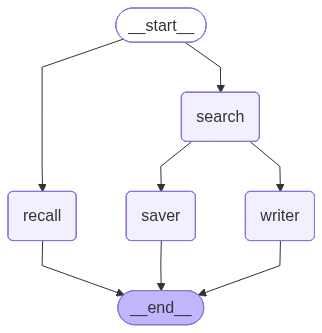

In [15]:
from typing import TypedDict, List, Optional
from langgraph.graph import StateGraph, END, START
from langgraph.store.base import BaseStore
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig

# --- 1. ĐỊNH NGHĨA STATE ---
class SubGraphState(TypedDict): 
  query: str
  context: str 
  
class MainState(TypedDict): 
  user_id: str 
  question: str 
  long_term_memory: str # lay du lieu tu store 
  working_context: str # dữ liệu lấy từ subgraph
  answer: str 
  
# --- 2. SUBGRAPH: LẤY CONTEXT TỨC THỜI ---
def retriever_node(state :SubGraphState): 
  return {"context": "Thông tin: Langgraph là 1 framework xây dựng AI Agent"}

sub_builder = StateGraph(SubGraphState)
sub_builder.add_node("retriever", retriever_node)
sub_builder.set_entry_point("retriever")
sub_builder.add_edge("retriever", END)

sub_graph = sub_builder.compile()

# --- 3. MAIN GRAPH NODES ---
def recall_memory_node(state: MainState, config: RunnableConfig, store: BaseStore): 
	user_id = state['user_id']
	memories = store.search(("memories", user_id))
    
	memory_text = ""
	if memories:
		print(memories[0])
		memory_text = memories[0].value.get("info", "")
  
	return {"long_term_memory": memory_text}

def call_subgraph_node(state: MainState): 
  res = sub_graph.invoke({"query": state["question"]})
  return {"working_context": res["context"]}

def writer_node(state: MainState): 
  prompt = f"""
    Sở thích người dùng (LTM): {state['long_term_memory']}
    Kiến thức tìm được: {state['working_context']}
    Câu hỏi: {state['question']}
    """
  answer = f"Chào bạn, dựa trên sở thích '{state['long_term_memory']}' của bạn, tôi xin trả lời..."
  return {"answer": answer}
     
def save_memory_node(state: MainState, store: BaseStore): 
	user_id = state['user_id']
	# Giả sử ta phát hiện user thích học về 'Graph'
	if "graph" in state["question"].lower():
			store.put(
					("memories", user_id), 
					"user_preference", 
					{"info": "Người dùng này quan tâm đến kiến trúc đồ thị."}
			)
	return {}

# --- 4. KẾT NỐI MAIN GRAPH ---
builder = StateGraph(MainState)

builder.add_node("recall", recall_memory_node)
builder.add_node("search", call_subgraph_node)
builder.add_node("writer", writer_node)
builder.add_node("saver", save_memory_node)

builder.set_entry_point("recall")
builder.set_entry_point("search")
builder.add_edge("search", "writer")
builder.add_edge("search", "saver")
# builder.add_edge("saver", END)
# builder.add_edge("writer", END)


memory = MemorySaver()
store = InMemoryStore()
app = builder.compile(checkpointer=memory, store=store)

from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [16]:
config = {"configurable": {"thread_id": "1", "user_id": "user_123"}}

input_1 = {"user_id": "user_123", "question": "LangGraph là gì?"}
app.invoke(input_1, config)

{'user_id': 'user_123',
 'question': 'LangGraph là gì?',
 'long_term_memory': '',
 'working_context': 'Thông tin: Langgraph là 1 framework xây dựng AI Agent',
 'answer': "Chào bạn, dựa trên sở thích '' của bạn, tôi xin trả lời..."}

In [17]:
config_2 = {"configurable": {"thread_id": "2", "user_id": "user_123"}}
input_2 = {"user_id": "user_123", "question": "Tại sao nó mạnh?"}
final_state = app.invoke(input_2, config_2)

print(final_state["answer"])

Item(namespace=['memories', 'user_123'], key='user_preference', value={'info': 'Người dùng này quan tâm đến kiến trúc đồ thị.'}, created_at='2026-01-18T06:18:25.565251+00:00', updated_at='2026-01-18T06:18:25.565253+00:00', score=None)
Chào bạn, dựa trên sở thích 'Người dùng này quan tâm đến kiến trúc đồ thị.' của bạn, tôi xin trả lời...


## 7. Map Reduce

In [30]:
from typing import TypedDict, Annotated, List
import operator
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

# 1. Định nghĩa State
class State(TypedDict): 
  subjects: List[str]
  reviews: Annotated[List[str], operator.add]
  
# 2. Node Worker (Map)
def worker_node(state: State): 
  # Mỗi worker chỉ nhận 1 chủ đề và xử lý nó
  subject = state['subject']
  return {"reviews": [f"Kết quả nghiên cứu cho chủ đề: {subject}"]}

# 3. Node Điều phối (Maper)
def map_subjects(state: State): 
  # Tạo ra các yêu cầu "Send" song song cho từng chủ đề
  return [Send("worker_node", {"subject": s}) for s in state['subjects']]

# 4. Node Tổng hợp (Reduce)
def reducer_node(state: State): 
  combined = "\n".join(state['reviews'])
  return {"reviews": [f"kết quả tổng hợp cuối cùng:\n{combined}"]}


graph = StateGraph(State)
graph.add_node("worker_node", worker_node)
graph.add_node("reducer_node", reducer_node)

# Dùng add_conditional_edges để kích hoạt Map-Reduce
graph.add_conditional_edges(START, map_subjects, "worker_node")
graph.add_edge("worker_node", "reducer_node")
graph.add_edge("reducer_node", END)

app = graph.compile()

res = app.invoke({"subjects": ["AI", "Computer Vision", "LLM", "NLP"]})
import pprint
pprint.pprint(res)
print('-' * 100)
pprint.pprint(res['reviews'][-1])

{'reviews': ['Kết quả nghiên cứu cho chủ đề: AI',
             'Kết quả nghiên cứu cho chủ đề: Computer Vision',
             'Kết quả nghiên cứu cho chủ đề: LLM',
             'Kết quả nghiên cứu cho chủ đề: NLP',
             'kết quả tổng hợp cuối cùng:\n'
             'Kết quả nghiên cứu cho chủ đề: AI\n'
             'Kết quả nghiên cứu cho chủ đề: Computer Vision\n'
             'Kết quả nghiên cứu cho chủ đề: LLM\n'
             'Kết quả nghiên cứu cho chủ đề: NLP'],
 'subjects': ['AI', 'Computer Vision', 'LLM', 'NLP']}
----------------------------------------------------------------------------------------------------
('kết quả tổng hợp cuối cùng:\n'
 'Kết quả nghiên cứu cho chủ đề: AI\n'
 'Kết quả nghiên cứu cho chủ đề: Computer Vision\n'
 'Kết quả nghiên cứu cho chủ đề: LLM\n'
 'Kết quả nghiên cứu cho chủ đề: NLP')
